# Fast Base Long Filter Strategy 2026

In [41]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import talib as ta


In [42]:
# Get Dataframe from Yahoo Finance
df = yf.download('BTC-USD', start='2018-01-01', end='2025-01-01')
df["Close"]
df["High"]
df["Low"]
df["Open"]
df["Volume"]
days = np.arange(len(df))
df["Days"] = days+1
#rearrange columns
df = df[["Days", "Open", "High", "Low", "Close", "Volume"]]
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Days,Open,High,Low,Close,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2018-01-01,1,14112.200195,14112.200195,13154.700195,13657.200195,10291200000
2018-01-02,2,13625.000000,15444.599609,13163.599609,14982.099609,16846600192
2018-01-03,3,14978.200195,15572.799805,14844.500000,15201.000000,16871900160
2018-01-04,4,15270.700195,15739.700195,14522.200195,15599.200195,21783199744
2018-01-05,5,15477.200195,17705.199219,15202.799805,17429.500000,23840899072


In [43]:
#-------------------/ Pretty Good Oscillator /-------------------#
PGO_length  = int(input("Enter the length for PGO: "))
lower_level = float(input("Enter the lower level for PGO: "))
upper_level = float(input("Enter the upper level for PGO: "))

def pgo(df, length=34):
    close = df['Close'].squeeze().values
    high  = df['High'].squeeze().values
    low   = df['Low'].squeeze().values

    sma = ta.SMA(close, timeperiod=length)
    atr = ta.ATR(high, low, close, timeperiod=length)
    return (close - sma) / atr

df['PGO'] = pgo(df, length=PGO_length)

long_PGO = df['PGO'] > upper_level
short_PGO = df['PGO'] < lower_level
color_PGO = np.where(long_PGO, 'green', np.where(short_PGO, 'red', 'gray'))


df.head()





Price,Days,Open,High,Low,Close,Volume,PGO
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
Date,,,,,,,
2018-01-01,1,14112.200195,14112.200195,13154.700195,13657.200195,10291200000,NaN
2018-01-02,2,13625.000000,15444.599609,13163.599609,14982.099609,16846600192,NaN
2018-01-03,3,14978.200195,15572.799805,14844.500000,15201.000000,16871900160,NaN
2018-01-04,4,15270.700195,15739.700195,14522.200195,15599.200195,21783199744,NaN
2018-01-05,5,15477.200195,17705.199219,15202.799805,17429.500000,23840899072,NaN


In [44]:
# =================/ Linear Regression and Volatility /=================

lin_length = int(input("Enter Linear Regression length: "))
offset_length = int(input("Enter Linear Regression offset length: "))

close = df['Close'].squeeze().values #SQUEEZE TO 1D ARRAY
high  = df['High'].squeeze().values
low   = df['Low'].squeeze().values

lin_reg = ta.LINEARREG(close, timeperiod=lin_length)

df["Linear Regression"] = lin_reg
long_linereg = close > df["Linear Regression"].values #CHANGE THIS TO 1D ARRAY
short_linereg = close < df["Linear Regression"].values

color_linereg = np.where(long_linereg, 'green', np.where(short_linereg, 'red', 'gray'))



In [45]:
#//========= / Standard Deviation EMA / =============//

ema_length = int(input("Enter EMA length for Standard Deviation: "))
std_multiplier = float(input("Enter Standard Deviation Multiplier: "))

ema = ta.EMA(close, timeperiod=ema_length)
std = ta.STDDEV(close, timeperiod=ema_length) * std_multiplier

upperband = ema + std
lowerband = ema - std

df['EMA Upperband'] = upperband
df['EMA Lowerband'] = lowerband
long_ema =close > df['EMA Upperband'].values
short_ema = close < df['EMA Lowerband'].values

color_ema = np.where(long_ema, 'green', np.where(short_ema, 'red', 'gray'))



In [46]:
#//========= / Gann Theory For Loop / =============//
from typing_extensions import final


start = int(input("Enter start for Gann Theory: "))
end = int(input("Enter end for Gann Theory: "))
up_threshold = float(input("Enter Upper threshold for Gann Theory: "))
down_threshold = float(input("Enter Lower threshold for Gann Theory: "))
gann_threshold = -15 # This is a default value, you can adjust it based on your needs

def system_forloop(df, src_col, start, end):
    src = df[src_col].values

    result = np.zeros(len(src))

    for row in range(len(src)):
        count = 0.0
        for i in range(start, end + 1):
            lookback_idx = row - i          # "i bars ago" from current row
            if lookback_idx < 0:
                continue                    # not enough history yet, skip
            past_close = src[lookback_idx]
            count += -1 if past_close > src[row] else 1
        result[row] = count

    return result

gann_theory_close = system_forloop(df, "Close", start, end)
gann_theory_high = system_forloop(df, "High", start, end)
gann_theory_low = system_forloop(df, "Low", start, end)

final_gann_theory = np.where(gann_theory_close > gann_threshold, gann_theory_high, gann_theory_low)
df["Gann Theory For Loop"] = final_gann_theory

long_gann = (final_gann_theory[:-1] <= up_threshold) & (final_gann_theory[1:] > up_threshold)
short_gann = (final_gann_theory[:-1] >= down_threshold) & (final_gann_theory[1:] < down_threshold)

long_gann = np.insert(long_gann, 0, False)
short_gann = np.insert(short_gann, 0, False)


gann_sig = np.zeros(len(final_gann_theory))

for i in range(1, len(final_gann_theory)):
    if long_gann[i] and not short_gann[i]:
        gann_sig[i] = 1
    elif short_gann[i]:
        gann_sig[i] = -1
    else:
        gann_sig[i] = gann_sig[i-1]

df["Long Gann"] = gann_sig == 1
df["Short Gann"] = gann_sig == -1
gann_color = np.where(df["Long Gann"].values == 1, 'teal', np.where(df["Short Gann"].values == -1, 'purple', 'purple'))





In [49]:
# returns
starting_equity = float(input("Enter the starting equity: "))
bh_equity = starting_equity
strategy_equity = starting_equity


df["BH Returns"] = bh_equity * (df["Close"] / df["Close"].shift(1)).cumprod()
df.head()


Price,Days,Open,High,Low,Close,Volume,PGO,Linear Regression,EMA Upperband,EMA Lowerband,Gann Theory For Loop,Long Gann,Short Gann,BH Returns
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,,,,,
Date,,,,,,,,,,,,,,
2018-01-01,1,14112.200195,14112.200195,13154.700195,13657.200195,10291200000,NaN,NaN,NaN,NaN,0.0,False,False,NaN
2018-01-02,2,13625.000000,15444.599609,13163.599609,14982.099609,16846600192,NaN,NaN,NaN,NaN,0.0,False,False,109.701106
2018-01-03,3,14978.200195,15572.799805,14844.500000,15201.000000,16871900160,NaN,NaN,NaN,NaN,0.0,False,False,111.303926
2018-01-04,4,15270.700195,15739.700195,14522.200195,15599.200195,21783199744,NaN,NaN,NaN,NaN,0.0,False,False,114.219606
2018-01-05,5,15477.200195,17705.199219,15202.799805,17429.500000,23840899072,NaN,NaN,NaN,NaN,0.0,False,False,127.621326


Text(0, 0.5, 'Value')

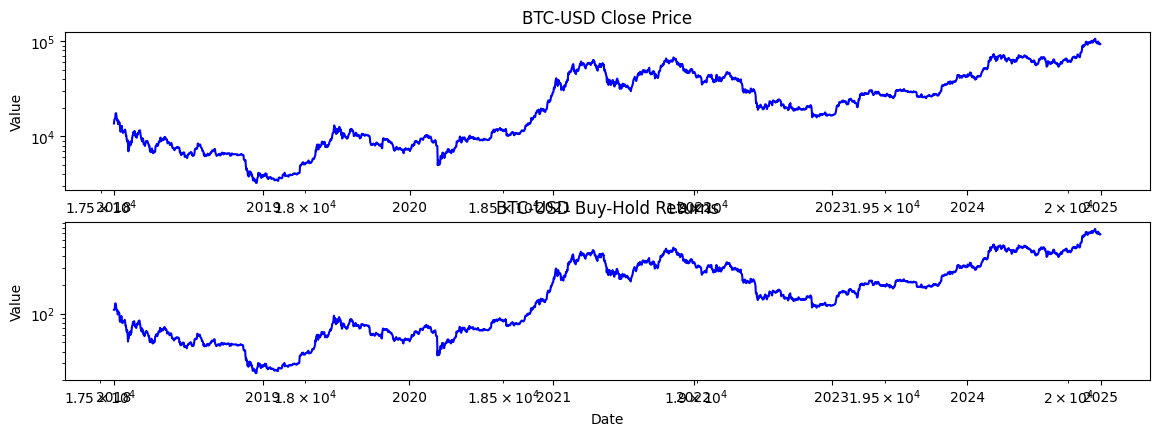

In [54]:
# Plottinfg
plt.figure(figsize=(14, 7))
plt.subplot(3, 1, 1)
plt.loglog(df.index,df["Close"], label="Close Price", color="blue")
plt.title("BTC-USD Close Price")
plt.xlabel("Date")
plt.ylabel("Value")

plt.subplot(3, 1, 2)
plt.loglog(df["BH Returns"], label="Buy-Hold Returns", color="blue")
plt.title("BTC-USD Buy-Hold Returns")
plt.xlabel("Date")
plt.ylabel("Value")



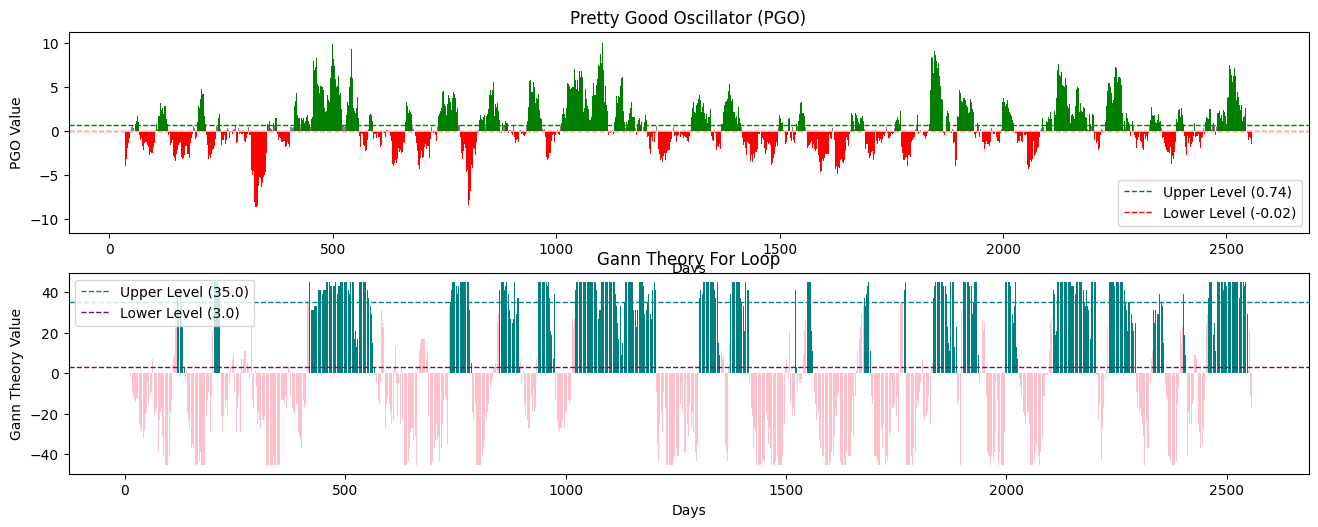

In [ ]:
# Subplot for Oscillators
plt.figure(figsize=(16, 12))
plt.subplot(4, 1, 1)
plt.bar(df["Days"], df["PGO"], color=color_PGO, width=1)
plt.axhline(y=upper_level, color='green', linestyle='--', linewidth=1, label=f'Upper Level ({upper_level})')
plt.axhline(y=lower_level, color='red',   linestyle='--', linewidth=1, label=f'Lower Level ({lower_level})')
plt.axhline(y=0,           color='white', linestyle='-',  linewidth=0.5)
plt.title("Pretty Good Oscillator (PGO)")
plt.xlabel("Days")
plt.ylabel("PGO Value")
plt.legend()

plt.subplot(4, 1, 2)
plt.bar(df["Days"], df["Gann Theory For Loop"], color=gann_color, linewidth=1)
plt.axhline(y=up_threshold, color='teal', linestyle='--', linewidth=1, label=f'Upper Level ({up_threshold})')
plt.axhline(y=down_threshold, color='purple',   linestyle='--', linewidth=1, label=f'Lower Level ({down_threshold})')
plt.title("Gann Theory For Loop")
plt.xlabel("Days")
plt.ylabel("Gann Theory Value")
plt.legend()
